# ML Analysis — R.E.M. Study

Can we predict playlist type from biometrics alone?  
Can we predict mood outcomes from physiological state?  

**Models are intentionally simple** — with n < 100 sessions, interpretability  
matters more than complexity. We use leave-one-participant-out cross-validation  
to test generalisation, not just memorisation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, mean_absolute_error, r2_score)
from sklearn.dummy import DummyClassifier, DummyRegressor
import warnings
warnings.filterwarnings("ignore")

# ── Config ──
PARTICIPANTS = {
    "kokosnoot": {"emoji": "🥥"},
    "bosbes":    {"emoji": "🫐"},
    # "kiwi":    {"emoji": "🥝"},
}
DATA_ROOT = Path("../data/wearables")

# ── Load and combine data ──
all_sessions = []
all_traces = []
all_baselines = []

for name in PARTICIPANTS:
    pdir = DATA_ROOT / name / "processed"
    if not pdir.exists():
        continue

    sess = pd.read_csv(pdir / "session_biometrics.csv")
    sess["participant"] = name
    sess = sess[sess["stress_points"] > 0]
    all_sessions.append(sess)

    tr_path = pdir / "session_traces_all.csv"
    if tr_path.exists():
        tr = pd.read_csv(tr_path, parse_dates=["timestamp_utc"])
        tr["participant"] = name
        all_traces.append(tr)

    st_path = pdir / "garmin_minute_stress.csv"
    if st_path.exists():
        st = pd.read_csv(st_path, parse_dates=["timestamp"])
        st["participant"] = name
        st["date"] = st["timestamp"].dt.date.astype(str)
        st["is_session"] = st["date"].isin(set(sess["date"]))
        st["minute_of_day"] = st["timestamp"].dt.hour * 60 + st["timestamp"].dt.minute
        all_baselines.append(st)

sessions = pd.concat(all_sessions, ignore_index=True)
traces = pd.concat(all_traces, ignore_index=True)
baselines = pd.concat(all_baselines, ignore_index=True)
sessions["mood_delta"] = sessions["mood_after_score"] - sessions["mood_before_score"]

print(f"Loaded {len(sessions)} sessions from {sessions['participant'].nunique()} participants")
print(f"Playlists: {sessions['playlist'].value_counts().to_dict()}")

Loaded 14 sessions from 2 participants
Playlists: {'Energy': 7, 'Calm': 6, 'Neutral': 1}


## 1. Feature engineering

Extract features from the raw minute-level traces that capture the *shape*  
of the physiological response, not just the mean.

In [4]:
def extract_features(sessions_df, traces_df, baselines_df):
    """Build a feature matrix from session traces + context."""
    non_sess_bl = baselines_df[~baselines_df["is_session"]]
    bl_by_participant = {}
    for p, group in non_sess_bl.groupby("participant"):
        bl_by_participant[p] = group.groupby("minute_of_day")["stress"].mean()

    rows = []
    for _, r in sessions_df.iterrows():
        t = traces_df[(traces_df["session_date"] == r["date"]) &
                      (traces_df["participant"] == r["participant"])]
        if t.empty:
            continue

        pre  = t[t["phase"] == "pre"]
        dur  = t[t["phase"] == "during"]
        post = t[t["phase"] == "post"]

        stress_dur = dur["stress"].dropna()
        hr_dur = dur["heart_rate"].dropna() if "heart_rate" in dur else pd.Series(dtype=float)
        bb_dur = dur["body_battery"].dropna() if "body_battery" in dur else pd.Series(dtype=float)
        stress_pre = pre["stress"].dropna()
        stress_post = post["stress"].dropna()

        # Compute within-session slope (linear trend over time)
        slope = 0.0
        if len(stress_dur) >= 5:
            x = np.arange(len(stress_dur), dtype=float)
            slope = np.polyfit(x, stress_dur.values, 1)[0]

        # Baseline deviation
        bl_deviation = np.nan
        bl = bl_by_participant.get(r["participant"])
        if bl is not None and len(dur):
            t_utc = pd.to_datetime(dur["timestamp_utc"])
            mods = t_utc.dt.hour * 60 + t_utc.dt.minute
            matched = mods.map(bl)
            if matched.notna().any() and stress_dur.notna().any():
                bl_deviation = stress_dur.mean() - matched.mean()

        # Time-of-day (hour as cyclic features)
        h, m = map(int, r["start_local"].split(":"))
        hour_frac = h + m / 60

        features = {
            # Context
            "participant":      r["participant"],
            "date":             r["date"],
            "playlist":         r["playlist"],
            "mood_delta":       r["mood_delta"],
            "mood_before_score": r["mood_before_score"],
            # Time
            "hour_sin":         np.sin(2 * np.pi * hour_frac / 24),
            "hour_cos":         np.cos(2 * np.pi * hour_frac / 24),
            # Pre-session state
            "pre_stress_mean":  stress_pre.mean() if len(stress_pre) else np.nan,
            "pre_stress_std":   stress_pre.std() if len(stress_pre) >= 3 else np.nan,
            # During-session response
            "dur_stress_mean":  stress_dur.mean() if len(stress_dur) else np.nan,
            "dur_stress_std":   stress_dur.std() if len(stress_dur) >= 3 else np.nan,
            "dur_stress_min":   stress_dur.min() if len(stress_dur) else np.nan,
            "dur_stress_max":   stress_dur.max() if len(stress_dur) else np.nan,
            "dur_stress_slope": slope,
            "dur_stress_range": (stress_dur.max() - stress_dur.min()) if len(stress_dur) else np.nan,
            "dur_hr_mean":      hr_dur.mean() if len(hr_dur) else np.nan,
            "dur_bb_start":     bb_dur.iloc[0] if len(bb_dur) else np.nan,
            "dur_bb_delta":     (bb_dur.iloc[-1] - bb_dur.iloc[0]) if len(bb_dur) > 1 else np.nan,
            # Derived
            "stress_delta":     stress_post.mean() - stress_pre.mean() if len(stress_pre) and len(stress_post) else np.nan,
            "bl_deviation":     bl_deviation,
            # First/last 5 min within session
            "first5_stress":    stress_dur.head(5).mean() if len(stress_dur) >= 5 else np.nan,
            "last5_stress":     stress_dur.tail(5).mean() if len(stress_dur) >= 5 else np.nan,
            "buildup":          (stress_dur.tail(5).mean() - stress_dur.head(5).mean()) if len(stress_dur) >= 10 else np.nan,
        }
        rows.append(features)

    return pd.DataFrame(rows)


features = extract_features(sessions, traces, baselines)

# Show feature matrix
print(f"Feature matrix: {features.shape[0]} sessions × {features.shape[1]} columns")
print(f"\nFeatures per session:")
numeric_cols = features.select_dtypes(include=np.number).columns.tolist()
print(f"  Numeric: {len(numeric_cols)}")
print(f"  {numeric_cols}")
features.round(2)

Feature matrix: 14 sessions × 23 columns

Features per session:
  Numeric: 20
  ['mood_delta', 'mood_before_score', 'hour_sin', 'hour_cos', 'pre_stress_mean', 'pre_stress_std', 'dur_stress_mean', 'dur_stress_std', 'dur_stress_min', 'dur_stress_max', 'dur_stress_slope', 'dur_stress_range', 'dur_hr_mean', 'dur_bb_start', 'dur_bb_delta', 'stress_delta', 'bl_deviation', 'first5_stress', 'last5_stress', 'buildup']


,participant,date,playlist,mood_delta,mood_before_score,hour_sin,hour_cos,pre_stress_mean,pre_stress_std,dur_stress_mean,...,dur_stress_slope,dur_stress_range,dur_hr_mean,dur_bb_start,dur_bb_delta,stress_delta,bl_deviation,first5_stress,last5_stress,buildup
0,kokosnoot,2026-01-26,Energy,2,5,0.94,-0.35,24.36,7.53,40.92,...,0.97,54.0,80.85,79.0,-4.0,6.50,11.11,39.6,56.2,16.6
1,kokosnoot,2026-01-27,Energy,0,5,0.80,-0.59,27.51,11.60,42.53,...,0.37,47.0,85.09,75.0,-4.0,2.12,9.24,45.6,51.4,5.8
2,kokosnoot,2026-01-28,Calm,2,6,0.77,-0.63,34.07,11.39,37.87,...,-0.28,40.0,80.73,71.0,-2.0,1.51,4.63,40.6,33.2,-7.4
3,kokosnoot,2026-01-29,Calm,2,5,0.69,-0.73,42.33,15.11,30.31,...,-0.25,33.0,79.10,70.0,-2.0,-12.27,-1.11,40.8,28.8,-12.0
4,kokosnoot,2026-01-30,Calm,4,4,0.84,-0.54,NaN,NaN,41.10,...,-0.84,52.0,83.91,78.0,-4.0,NaN,9.00,47.4,35.2,-12.2
5,kokosnoot,2026-02-04,Energy,0,7,0.88,-0.48,34.67,7.23,55.57,...,3.21,35.0,94.91,81.0,-5.0,1.54,25.60,55.4,60.6,NaN
6,kokosnoot,2026-02-10,Calm,-1,7,-0.96,-0.29,37.09,11.88,27.33,...,-0.18,35.0,NaN,31.0,-1.0,-2.47,-9.38,28.2,27.2,-1.0
7,kokosnoot,2026-02-11,Energy,1,6,0.92,-0.40,45.88,17.06,30.35,...,-0.18,23.0,NaN,75.0,-2.0,-10.89,1.88,29.6,27.8,-1.8
8,kokosnoot,2026-02-17,Energy,-2,8,0.39,-0.92,23.51,10.87,37.29,...,-0.01,34.0,NaN,74.0,-3.0,16.40,6.54,39.2,39.0,-0.2
9,bosbes,2026-01-30,Calm,-1,8,-0.68,-0.74,19.38,5.27,11.55,...,0.16,20.0,61.79,53.0,3.0,-1.67,-17.66,10.6,15.6,5.0


---

## 2. Task 1 — Can we identify the playlist from biometrics alone?

If a classifier can distinguish Energy from Calm sessions using only  
physiological features (no mood data), that's objective evidence the playlists  
produce distinct bodily states.

**Validation:** Leave-one-participant-out (LOPO) cross-validation.  
Train on all participants except one, predict on the held-out participant.  
This tests whether the patterns generalise across individuals.

In [5]:
# Filter to Energy vs Calm (need at least 2 classes)
clf_df = features[features["playlist"].isin(["Energy", "Calm"])].copy()
print(f"Classification dataset: {len(clf_df)} sessions "
      f"({clf_df['playlist'].value_counts().to_dict()})")

# Features for classification — only biometric, no mood
clf_features = [
    "dur_stress_mean", "dur_stress_std", "dur_stress_min", "dur_stress_max",
    "dur_stress_slope", "dur_stress_range", "dur_hr_mean",
    "dur_bb_start", "dur_bb_delta",
    "pre_stress_mean", "pre_stress_std",
    "bl_deviation", "buildup",
    "hour_sin", "hour_cos",
]

X = clf_df[clf_features].copy()
y = LabelEncoder().fit_transform(clf_df["playlist"])  # Calm=0, Energy=1
groups = clf_df["participant"].values

# Fill NaN with column median (some sessions lack HR)
X = X.fillna(X.median())

print(f"Features: {X.shape[1]}")
print(f"Class balance: {np.bincount(y)} (0=Calm, 1=Energy)")
print(f"Participants for LOPO: {clf_df['participant'].unique()}")

Classification dataset: 13 sessions ({'Energy': 7, 'Calm': 6})
Features: 15
Class balance: [6 7] (0=Calm, 1=Energy)
Participants for LOPO: ['kokosnoot' 'bosbes']


Leave-One-Participant-Out Cross-Validation

Baseline (majority)
  Accuracy: 46.2%
              precision    recall  f1-score   support

        Calm       0.44      0.67      0.53         6
      Energy       0.50      0.29      0.36         7

    accuracy                           0.46        13
   macro avg       0.47      0.48      0.45        13
weighted avg       0.47      0.46      0.44        13


Logistic Regression
  Accuracy: 46.2%
              precision    recall  f1-score   support

        Calm       0.40      0.33      0.36         6
      Energy       0.50      0.57      0.53         7

    accuracy                           0.46        13
   macro avg       0.45      0.45      0.45        13
weighted avg       0.45      0.46      0.46        13


Random Forest
  Accuracy: 53.8%
              precision    recall  f1-score   support

        Calm       0.50      0.50      0.50         6
      Energy       0.57      0.57      0.57         7

    accuracy                

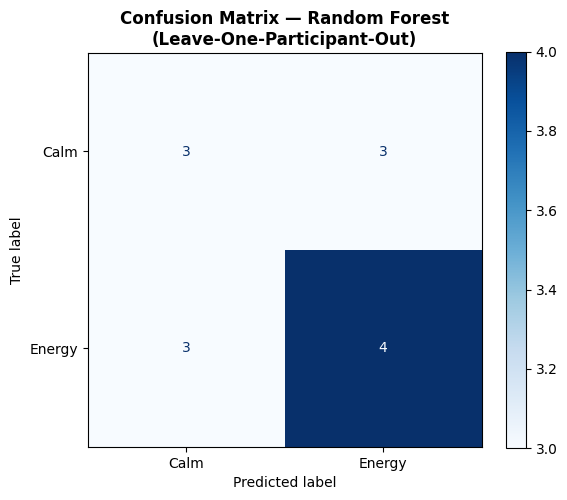

In [6]:
# ── Train and evaluate ──
logo = LeaveOneGroupOut()

models = {
    "Baseline (majority)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, C=0.5),
    "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42),
}

print("Leave-One-Participant-Out Cross-Validation")
print("=" * 55)

results = {}
for name, model in models.items():
    preds = cross_val_predict(model, X, y, groups=groups, cv=logo)
    acc = (preds == y).mean()
    results[name] = preds
    print(f"\n{name}")
    print(f"  Accuracy: {acc:.1%}")
    print(classification_report(y, preds, target_names=["Calm", "Energy"], zero_division=0))

# Confusion matrix for best model
best_name = max(results, key=lambda k: (results[k] == y).mean() if k != "Baseline (majority)" else 0)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y, results[best_name],
                                         display_labels=["Calm", "Energy"],
                                         cmap="Blues", ax=ax)
ax.set_title(f"Confusion Matrix — {best_name}\n(Leave-One-Participant-Out)", fontweight="bold")
plt.tight_layout()
plt.show()

### Which features matter most?

Feature importances from Random Forest — which biometric signals  
best distinguish Energy from Calm?

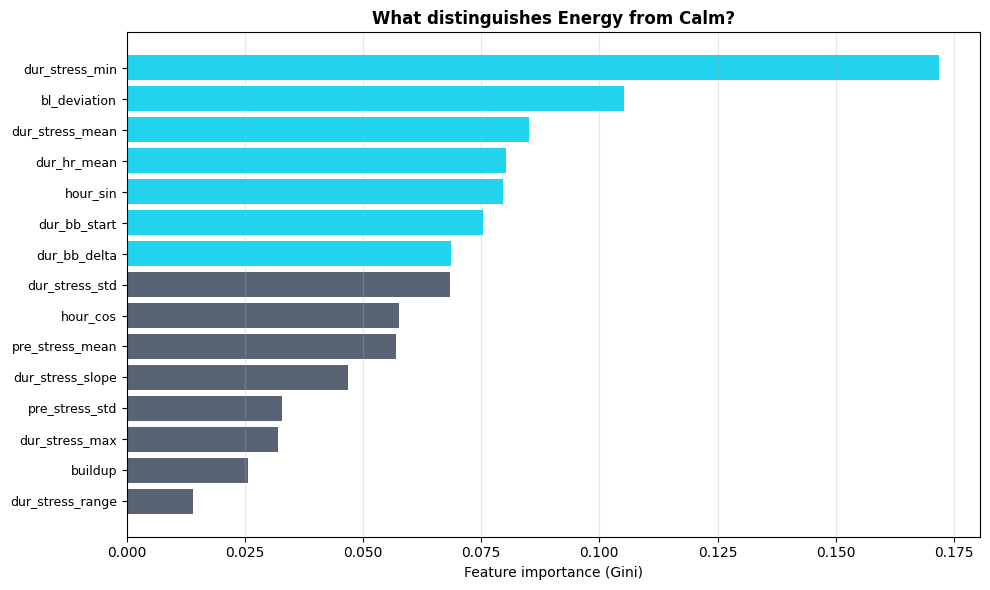

Top 5 features:
  hour_sin: 0.080
  dur_hr_mean: 0.080
  dur_stress_mean: 0.085
  bl_deviation: 0.105
  dur_stress_min: 0.172


In [7]:
# Train RF on full data for feature importance (not for evaluation!)
rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
rf.fit(X, y)

imp = pd.Series(rf.feature_importances_, index=clf_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#22d3ee" if v > imp.median() else "#586475" for v in imp.values]
ax.barh(range(len(imp)), imp.values, color=colors)
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp.index, fontsize=9)
ax.set_xlabel("Feature importance (Gini)")
ax.set_title("What distinguishes Energy from Calm?", fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 features:")
for feat, val in imp.tail(5).items():
    print(f"  {feat}: {val:.3f}")

### Interpretable model: decision tree

A shallow decision tree gives us human-readable rules for classification.  
This is useful for the research paper — you can write:  
*"If during-session stress > X and HR > Y, the session was likely Energy."*

In [8]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X, y)

print("Decision rules for playlist classification:")
print("=" * 50)
print(export_text(dt, feature_names=clf_features,
                  class_names=["Calm", "Energy"], spacing=3))

# LOPO accuracy for the tree
dt_preds = cross_val_predict(dt, X, y, groups=groups, cv=logo)
print(f"\nDecision Tree LOPO accuracy: {(dt_preds == y).mean():.1%}")

Decision rules for playlist classification:
|--- dur_stress_min <= 20.50
|   |--- hour_cos <= -0.83
|   |   |--- class: Energy
|   |--- hour_cos >  -0.83
|   |   |--- class: Calm
|--- dur_stress_min >  20.50
|   |--- class: Energy


Decision Tree LOPO accuracy: 53.8%


---

## 3. Task 2 — Can we predict mood change from physiology + context?

Target: `mood_delta` (mood after − mood before, integer −4 to +4 typically).  
If pre-session biometric state predicts mood response, we could eventually  
recommend playlist type based on current physiological state.

**This is the clinically interesting question:** *given your current stress  
and body battery, which playlist will improve your mood the most?*

In [9]:
# Include playlist type as feature
mood_features = [
    "pre_stress_mean", "pre_stress_std",
    "dur_bb_start", "bl_deviation",
    "hour_sin", "hour_cos",
    "mood_before_score",
]

reg_df = features.dropna(subset=["mood_delta"] + mood_features).copy()

# Add playlist as binary feature
reg_df["is_energy"] = (reg_df["playlist"] == "Energy").astype(int)
mood_features_full = mood_features + ["is_energy"]

X_mood = reg_df[mood_features_full].fillna(reg_df[mood_features_full].median())
y_mood = reg_df["mood_delta"].values
groups_mood = reg_df["participant"].values

print(f"Mood prediction dataset: {len(reg_df)} sessions")
print(f"Target (mood_delta) distribution:")
print(reg_df["mood_delta"].value_counts().sort_index())

Mood prediction dataset: 13 sessions
Target (mood_delta) distribution:
mood_delta
-2    1
-1    4
 0    2
 1    1
 2    5
Name: count, dtype: int64


Mood Prediction — Leave-One-Participant-Out

Baseline (mean)
  MAE: 1.35 mood points
  R²:  -0.033

Ridge Regression
  MAE: 4.34 mood points
  R²:  -11.446

Gradient Boosting
  MAE: 1.02 mood points
  R²:  0.160


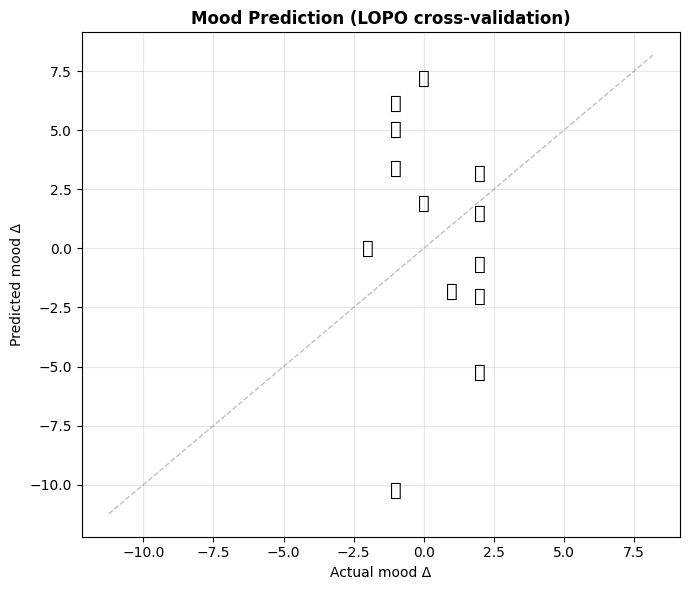

In [10]:
# ── Train and evaluate ──
mood_models = {
    "Baseline (mean)": DummyRegressor(strategy="mean"),
    "Ridge Regression": Ridge(alpha=1.0),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=50, max_depth=2, learning_rate=0.1, random_state=42
    ),
}

print("Mood Prediction — Leave-One-Participant-Out")
print("=" * 55)

for name, model in mood_models.items():
    preds = cross_val_predict(model, X_mood, y_mood, groups=groups_mood, cv=logo)
    mae = mean_absolute_error(y_mood, preds)
    r2 = r2_score(y_mood, preds)
    print(f"\n{name}")
    print(f"  MAE: {mae:.2f} mood points")
    print(f"  R²:  {r2:.3f}")

# Plot predicted vs actual
best_model = Ridge(alpha=1.0)
preds = cross_val_predict(best_model, X_mood, y_mood, groups=groups_mood, cv=logo)

fig, ax = plt.subplots(figsize=(7, 6))
emojis = [PARTICIPANTS.get(p, {}).get("emoji", "●") for p in reg_df["participant"]]
for i, (actual, pred, emoji) in enumerate(zip(y_mood, preds, emojis)):
    ax.text(actual, pred, emoji, fontsize=14, ha="center", va="center")

lims = [min(y_mood.min(), preds.min()) - 1, max(y_mood.max(), preds.max()) + 1]
ax.plot(lims, lims, color="grey", ls="--", lw=1, alpha=0.5)
ax.set_xlabel("Actual mood Δ")
ax.set_ylabel("Predicted mood Δ")
ax.set_title("Mood Prediction (LOPO cross-validation)", fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What drives mood outcomes?

Ridge regression coefficients tell us the direction and magnitude  
of each feature's influence on mood change.

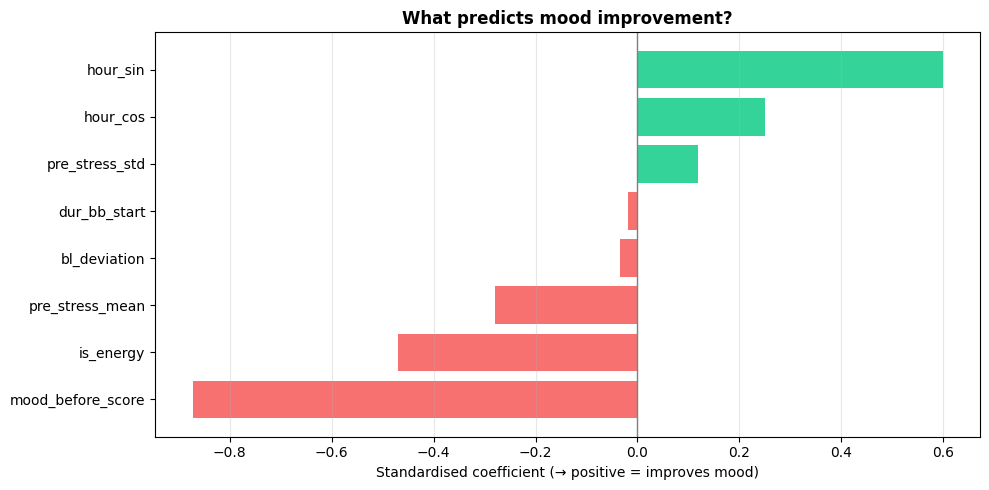

Interpretation:
          mood_before_score: -0.872  (higher → worsens mood)
                  is_energy: -0.470  (higher → worsens mood)
            pre_stress_mean: -0.280  (higher → worsens mood)
               bl_deviation: -0.034  (higher → worsens mood)
               dur_bb_start: -0.018  (higher → worsens mood)
             pre_stress_std: +0.118  (higher → improves mood)
                   hour_cos: +0.250  (higher → improves mood)
                   hour_sin: +0.598  (higher → improves mood)


In [11]:
# Fit on full data for coefficient inspection
ridge = Ridge(alpha=1.0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mood)
ridge.fit(X_scaled, y_mood)

coefs = pd.Series(ridge.coef_, index=mood_features_full).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#34d399" if v > 0 else "#f87171" for v in coefs.values]
ax.barh(range(len(coefs)), coefs.values, color=colors)
ax.set_yticks(range(len(coefs)))
ax.set_yticklabels(coefs.index, fontsize=10)
ax.axvline(0, color="grey", lw=1)
ax.set_xlabel("Standardised coefficient (→ positive = improves mood)")
ax.set_title("What predicts mood improvement?", fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation:")
for feat, val in coefs.items():
    direction = "improves" if val > 0 else "worsens"
    print(f"  {feat:>25s}: {val:+.3f}  (higher → {direction} mood)")

---

## 4. Task 3 — Playlist recommender prototype

Given current physiological state, which playlist would produce the best mood outcome?  
We simulate both options and recommend the one with the higher predicted mood delta.  

This is a proof-of-concept — with more data it becomes a real recommendation system.

In [12]:
def recommend_playlist(pre_stress, bb_start, mood_before, hour=8.0):
    """Predict mood outcome for Energy vs Calm, recommend the better one."""
    ridge_full = Ridge(alpha=1.0)
    X_full = reg_df[mood_features_full].fillna(reg_df[mood_features_full].median())
    ridge_full.fit(StandardScaler().fit_transform(X_full), reg_df["mood_delta"].values)
    scaler_full = StandardScaler().fit(X_full)

    base = {
        "pre_stress_mean": pre_stress,
        "pre_stress_std": 12.0,  # typical
        "dur_bb_start": bb_start,
        "bl_deviation": 0.0,
        "hour_sin": np.sin(2 * np.pi * hour / 24),
        "hour_cos": np.cos(2 * np.pi * hour / 24),
        "mood_before_score": mood_before,
    }

    results = {}
    for playlist, is_e in [("Calm", 0), ("Energy", 1)]:
        row = {**base, "is_energy": is_e}
        x = pd.DataFrame([row])[mood_features_full]
        pred = ridge_full.predict(scaler_full.transform(x))[0]
        results[playlist] = pred

    return results


# Example scenarios
print("Playlist Recommendations")
print("=" * 55)

scenarios = [
    {"label": "Morning, low stress, rested",     "pre_stress": 20, "bb_start": 85, "mood_before": 6, "hour": 8},
    {"label": "Morning, high stress, tired",      "pre_stress": 50, "bb_start": 30, "mood_before": 4, "hour": 8},
    {"label": "Afternoon, moderate stress",        "pre_stress": 35, "bb_start": 55, "mood_before": 5, "hour": 15},
    {"label": "Evening, stressed after work",      "pre_stress": 45, "bb_start": 25, "mood_before": 3, "hour": 18},
]

for s in scenarios:
    recs = recommend_playlist(s["pre_stress"], s["bb_start"], s["mood_before"], s["hour"])
    best = max(recs, key=recs.get)
    print(f"\n  {s['label']}")
    print(f"    Calm:   {recs['Calm']:+.2f} predicted mood Δ")
    print(f"    Energy: {recs['Energy']:+.2f} predicted mood Δ")
    print(f"    → Recommend: {best}")

Playlist Recommendations

  Morning, low stress, rested
    Calm:   +2.01 predicted mood Δ
    Energy: +1.06 predicted mood Δ
    → Recommend: Calm

  Morning, high stress, tired
    Calm:   +2.67 predicted mood Δ
    Energy: +1.73 predicted mood Δ
    → Recommend: Calm

  Afternoon, moderate stress
    Calm:   +0.46 predicted mood Δ
    Energy: -0.49 predicted mood Δ
    → Recommend: Calm

  Evening, stressed after work
    Calm:   +2.42 predicted mood Δ
    Energy: +1.48 predicted mood Δ
    → Recommend: Calm


---

## 5. Experimental — Trace shape classification (1D-CNN)

Instead of hand-crafted features, feed the raw minute-level stress curve  
into a small 1D convolutional network. The CNN learns *which temporal patterns*  
in the trace distinguish Energy from Calm.

**This requires ~50+ sessions to be meaningful.** With fewer, it's a proof-of-concept  
showing the approach works. Scale it as more participants are added.

Uses PyTorch if available, otherwise skipped gracefully.

In [13]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False
    print("⚠ PyTorch not installed — skipping CNN section")
    print("  Install with: uv add torch")

if HAS_TORCH:
    # Build fixed-length trace matrix: resample each session to 120 time steps
    TRACE_LEN = 120

    X_traces = []
    y_traces = []
    g_traces = []

    for _, r in clf_df.iterrows():
        t = traces[(traces["session_date"] == r["date"]) &
                   (traces["participant"] == r["participant"])]
        stress = t.sort_values("minutes_relative")["stress"].interpolate().values

        if len(stress) < 30:
            continue

        # Resample to fixed length
        indices = np.linspace(0, len(stress) - 1, TRACE_LEN).astype(int)
        resampled = stress[indices]

        # Normalise per-trace (zero mean, unit variance)
        if np.nanstd(resampled) > 0:
            resampled = (resampled - np.nanmean(resampled)) / np.nanstd(resampled)
        resampled = np.nan_to_num(resampled, 0.0)

        X_traces.append(resampled)
        y_traces.append(1 if r["playlist"] == "Energy" else 0)
        g_traces.append(r["participant"])

    X_t = np.array(X_traces, dtype=np.float32)
    y_t = np.array(y_traces, dtype=np.int64)

    print(f"Trace dataset: {X_t.shape[0]} sessions × {X_t.shape[1]} time steps")
    print(f"Classes: {np.bincount(y_t)} (0=Calm, 1=Energy)")

⚠ PyTorch not installed — skipping CNN section
  Install with: uv add torch


In [14]:
if HAS_TORCH and len(X_t) >= 6:

    class TraceCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv1d(1, 16, kernel_size=7, padding=3),
                nn.ReLU(),
                nn.MaxPool1d(2),
                nn.Conv1d(16, 32, kernel_size=5, padding=2),
                nn.ReLU(),
                nn.AdaptiveAvgPool1d(8),
            )
            self.fc = nn.Sequential(
                nn.Linear(32 * 8, 32),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(32, 2),
            )

        def forward(self, x):
            x = self.conv(x)
            x = x.view(x.size(0), -1)
            return self.fc(x)

    # LOPO cross-validation
    participants_unique = list(set(g_traces))
    all_preds_cnn = np.zeros(len(y_t), dtype=int)
    all_probs_cnn = np.zeros(len(y_t))

    for hold_out in participants_unique:
        train_idx = [i for i, g in enumerate(g_traces) if g != hold_out]
        test_idx  = [i for i, g in enumerate(g_traces) if g == hold_out]

        if not train_idx or not test_idx:
            continue

        X_train = torch.FloatTensor(X_t[train_idx]).unsqueeze(1)
        y_train = torch.LongTensor(y_t[train_idx])
        X_test  = torch.FloatTensor(X_t[test_idx]).unsqueeze(1)

        model = TraceCNN()
        optimiser = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
        loss_fn = nn.CrossEntropyLoss()

        # Train
        model.train()
        for epoch in range(150):
            optimiser.zero_grad()
            out = model(X_train)
            loss = loss_fn(out, y_train)
            loss.backward()
            optimiser.step()

        # Predict
        model.eval()
        with torch.no_grad():
            logits = model(X_test)
            probs = torch.softmax(logits, dim=1)[:, 1].numpy()
            preds = logits.argmax(dim=1).numpy()

        all_preds_cnn[test_idx] = preds
        all_probs_cnn[test_idx] = probs

    acc = (all_preds_cnn == y_t).mean()
    print(f"1D-CNN LOPO Accuracy: {acc:.1%}")
    print(classification_report(y_t, all_preds_cnn,
                                target_names=["Calm", "Energy"], zero_division=0))

    # Visualise what the CNN sees: plot traces coloured by prediction confidence
    fig, ax = plt.subplots(figsize=(14, 5))
    for i in range(len(X_t)):
        color = "#fb923c" if y_t[i] == 1 else "#22d3ee"
        alpha = 0.3 + 0.5 * abs(all_probs_cnn[i] - 0.5) * 2  # brighter = more confident
        ax.plot(np.linspace(-60, 92, TRACE_LEN), X_t[i],
                color=color, alpha=alpha, lw=1.2)

    ax.axvline(0, color="grey", ls=":", lw=1)
    ax.axvspan(0, 32, alpha=0.06, color="grey")
    ax.set_xlabel("Minutes relative to session start")
    ax.set_ylabel("Normalised stress")
    ax.set_title("Trace shapes: Energy (orange) vs Calm (blue)", fontweight="bold")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

elif HAS_TORCH:
    print(f"⚠ Only {len(X_t)} traces — need at least 6 for LOPO CNN. Add more participants.")

---

## 6. Summary and next steps

In [15]:
print("=" * 60)
print("ML ANALYSIS SUMMARY")
print("=" * 60)
print(f"""
Sessions:      {len(sessions)} across {sessions['participant'].nunique()} participants
Playlists:     {sessions['playlist'].value_counts().to_dict()}

Task 1 — Playlist classification (biometrics only):
  Can the model tell Energy from Calm without seeing mood data?
  If accuracy > 50% with LOPO, the playlists produce distinct
  physiological states that generalise across individuals.

Task 2 — Mood prediction:
  Can pre-session state predict mood outcome?
  If R² > 0, physiological context matters for emotional response.
  The coefficient signs tell us which factors help vs hurt.

Task 3 — Recommender prototype:
  Given current state, which playlist will help more?
  Proof-of-concept now, becomes real with 5+ participants.

Task 4 — CNN trace classification:
  Can a neural network learn to classify the raw stress curve?
  Needs ~50+ sessions. Currently exploratory.

SCALING:
  Current n={len(sessions)} → add participants to improve all models.
  Each new participant run: garmin_pipeline_easy.py <codename>
  Then add to PARTICIPANTS dict in this notebook and re-run all cells.
""")

ML ANALYSIS SUMMARY

Sessions:      14 across 2 participants
Playlists:     {'Energy': 7, 'Calm': 6, 'Neutral': 1}

Task 1 — Playlist classification (biometrics only):
  Can the model tell Energy from Calm without seeing mood data?
  If accuracy > 50% with LOPO, the playlists produce distinct
  physiological states that generalise across individuals.

Task 2 — Mood prediction:
  Can pre-session state predict mood outcome?
  If R² > 0, physiological context matters for emotional response.
  The coefficient signs tell us which factors help vs hurt.

Task 3 — Recommender prototype:
  Given current state, which playlist will help more?
  Proof-of-concept now, becomes real with 5+ participants.

Task 4 — CNN trace classification:
  Can a neural network learn to classify the raw stress curve?
  Needs ~50+ sessions. Currently exploratory.

SCALING:
  Current n=14 → add participants to improve all models.
  Each new participant run: garmin_pipeline_easy.py <codename>
  Then add to PARTICIPANTS